# Analyze TV market trends based on price, rating, and features

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ---------- LISTS ----------
brand = []
screen_size = []
resolution = []
tv_type = []
year = []
ratings = []
price = []
warranty = []

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/143.0.0.0 Safari/537.36"
}

# ---------- MULTI PAGE SCRAPING ----------
for page in range(1, 44):   

    url = f"https://www.flipkart.com/search?q=televisions&page={page}"
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, "html.parser")
        products = soup.find_all("div", class_="ZFwe0M row")

        for prod in products:

            # ---------- PRODUCT NAME ----------
            title_tag = prod.find("div", class_="RG5Slk")

            if title_tag:
                name_text = title_tag.text.strip()

                # Safe brand extraction
                brand.append(name_text.split()[0] if name_text.split() else "NA")

                # Screen size
                size_match = re.search(r"(\d+)\s*cm", name_text)
                screen_size.append(int(size_match.group(1)) if size_match else "NA")

                # Resolution
                if "4K" in name_text or "Ultra HD" in name_text:
                    resolution.append("4K Ultra HD")
                elif "Full HD" in name_text:
                    resolution.append("Full HD")
                elif "HD Ready" in name_text:
                    resolution.append("HD Ready")
                else:
                    resolution.append("NA")

                # TV type
                if "QLED" in name_text:
                    tv_type.append("QLED")
                elif "OLED" in name_text:
                    tv_type.append("OLED")
                elif "LED" in name_text:
                    tv_type.append("LED")
                else:
                    tv_type.append("NA")

                # Launch year
                year_match = re.search(r"(20\d{2})", name_text)
                year.append(year_match.group(1) if year_match else "NA")

            else:
                brand.append("NA")
                screen_size.append("NA")
                resolution.append("NA")
                tv_type.append("NA")
                year.append("NA")
                
            # ---------- STAR RATING ----------
            star_div = prod.find("div", class_="MKiFS6")
            ratings.append(float(star_div.text.strip()) if star_div else "NA")

            # ---------- PRICE ----------
            price_tag = prod.find("div", class_="hZ3P6w")
            price.append(int(re.sub(r"[^\d]", "", price_tag.text)) if price_tag else "NA")

            # ---------- WARRANTY ----------
            warranty_tag = prod.find(lambda tag: tag.name == "div" and "warranty" in tag.text.lower())
            if warranty_tag:
                warranty_text = warranty_tag.text.strip()
                match = re.search(
                    r"(\d+)\s*(year|years|yr|yrs|month|months)",
                    warranty_text,
                    re.IGNORECASE
                )
                warranty.append(match.group(0) if match else None)
            else:
                warranty.append(None)



In [3]:
df = pd.DataFrame({
    "Brand": brand,
    "Screen_Size_cm": screen_size,
    "Resolution": resolution,
    "TV_Type": tv_type,
    "Launch_Year": year,
    "Rating": ratings,
    "Price": price,
    "Warranty": warranty
})

In [4]:
df

,Brand,Screen_Size_cm,Resolution,TV_Type,Launch_Year,Rating,Price,Warranty
0,VW,80,HD Ready,LED,2025,4.0,7899,1 year
1,PHILIPS,189,4K Ultra HD,LED,2026,4.2,79999,1 Year
2,Foxsky,109,Full HD,QLED,2026,4.1,13999,1 Year
3,VW,60,HD Ready,LED,2025,4.0,4799,1 year
4,Coocaa,189,4K Ultra HD,LED,2026,4.2,59999,1 Year
...,...,...,...,...,...,...,...,...
979,Samsung,138,4K Ultra HD,LED,NA,3.3,48990,1 Year
980,NU,7,4K Ultra HD,LED,NA,NA,34999,1 Year
981,TRUSENSE,109,4K Ultra HD,LED,NA,NA,26474,None
982,Samsung,7,4K Ultra HD,QLED,2024,NA,65401,2 Year


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Brand           984 non-null    object
 1   Screen_Size_cm  984 non-null    object
 2   Resolution      984 non-null    object
 3   TV_Type         984 non-null    object
 4   Launch_Year     984 non-null    object
 5   Rating          984 non-null    object
 6   Price           984 non-null    object
 7   Warranty        925 non-null    object
dtypes: object(8)
memory usage: 61.6+ KB


In [6]:
df.head()

,Brand,Screen_Size_cm,Resolution,TV_Type,Launch_Year,Rating,Price,Warranty
0,VW,80,HD Ready,LED,2025,4.0,7899,1 year
1,PHILIPS,189,4K Ultra HD,LED,2026,4.2,79999,1 Year
2,Foxsky,109,Full HD,QLED,2026,4.1,13999,1 Year
3,VW,60,HD Ready,LED,2025,4.0,4799,1 year
4,Coocaa,189,4K Ultra HD,LED,2026,4.2,59999,1 Year


In [7]:
df['Warranty'].unique()

array(['1 year', '1 Year', None, '12 Month', '2 Year', '5 year',
       '12 month', '3 Year', '3 year', '2year', '1 YEAR', '2 year'],
      dtype=object)

In [8]:
df['Price'].unique()

array([7899, 79999, 13999, 4799, 59999, 7090, 7499, 5299, 11999, 5190,
       5399, 6899, 23499, 8799, 10699, 17799, 11799, 13799, 8499, 12999,
       8399, 35999, 77990, 22490, 14499, 9499, 11199, 13499, 5090, 9999,
       19999, 17999, 11990, 28999, 8299, 24999, 10499, 22999, 19499,
       40990, 41999, 8999, 36990, 27990, 34990, 26999, 25999, 22499, 8699,
       15999, 15499, 37998, 25499, 10899, 12990, 6399, 29990, 49499,
       14999, 23099, 27989, 20999, 37199, 34999, 30499, 9990, 24499,
       52999, 40999, 53499, 44990, 31999, 47999, 8490, 63990, 11490, 5290,
       15490, 39999, 16499, 13990, 26499, 64990, 28499, 36490, 79990,
       18499, 58490, 28998, 53699, 27999, 37999, 21999, 61990, 20499,
       53999, 29999, 62990, 38990, 54990, 52990, 11810, 13299, 13590,
       28990, 19799, 36999, 14190, 54999, 10999, 69699, 21499, 29499,
       24586, 134999, 69990, 74990, 83999, 38999, 28550, 6499, 39490,
       32499, 43999, 23999, 42999, 13314, 129990, 72990, 30999, 21199,
     

In [9]:
df['Launch_Year'].unique()

array(['2025', '2026', 'NA', '2024', '2022', '2000'], dtype=object)

In [10]:
df['Screen_Size_cm'].unique()

array([80, 189, 109, 60, 101, 138, 108, 100, 164, 8, 126, 102, 139, 165,
       4, 7, 127, 2, 140, 125, 163, 191, 215, 216, 9, 3, 1, 97, 78, 6,
       190, 28, 106, 110, 23, 43, 68, 5, 81, 'NA', 104, 148, 83, 98, 22,
       124, 177, 44, 291, 123, 253, 214, 176, 71, 64], dtype=object)

In [11]:
df['Rating'].unique()

array([4.0, 4.2, 4.1, 4.3, 3.9, 4.4, 4.5, 4.6, 3.5, 3.7, 3.4, 3.0, 5.0,
       'NA', 3.3, 3.8, 1.0, 4.8, 4.7, 2.8, 3.6, 3.2, 1.3, 2.7, 3.1, 2.3,
       4.9], dtype=object)

In [12]:
cols = ['Launch_Year', 'Screen_Size_cm', 'Rating','Warranty','Resolution','TV_Type','Price']
df[cols] = df[cols].replace(['NA', 'na', '', ' ','None'], np.nan)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3190475080.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].replace(['NA', 'na', '', ' ','None'], np.nan)


In [13]:
### handling datatypes
df['Screen_Size_cm'] = df['Screen_Size_cm'].astype('float')

In [14]:
df['Launch_Year'] = df['Launch_Year'].astype('float')

In [15]:
df['Price'] = df['Price'].astype('float')

In [16]:
df['Rating'] = df['Rating'].astype('float')

In [17]:
#checking for missing values
df.isna().sum()

Brand               0
Screen_Size_cm      4
Resolution          3
TV_Type            10
Launch_Year       748
Rating            186
Price               4
Warranty           59
dtype: int64

In [18]:
# filling the null values
df['Screen_Size_cm'].fillna(df['Screen_Size_cm'].median(), inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\2819322891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Screen_Size_cm'].fillna(df['Screen_Size_cm'].median(), inplace=True)


In [19]:
df['Resolution'].fillna(df['Resolution'].mode()[0], inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\1498122068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Resolution'].fillna(df['Resolution'].mode()[0], inplace=True)


In [20]:
df['TV_Type'].fillna(df['TV_Type'].mode()[0], inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\502110850.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TV_Type'].fillna(df['TV_Type'].mode()[0], inplace=True)


In [21]:
df['Launch_Year'].fillna(df['Launch_Year'].mode()[0], inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\55260047.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Launch_Year'].fillna(df['Launch_Year'].mode()[0], inplace=True)


In [22]:
df['Rating'].fillna(df['Rating'].mean(), inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\1501272357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace=True)


In [23]:
df['Warranty'].fillna(df['Warranty'].mode()[0], inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\2756716946.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Warranty'].fillna(df['Warranty'].mode()[0], inplace=True)


In [24]:
df['Price'].fillna(df['Price'].median(), inplace=True)

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3200313070.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].median(), inplace=True)


In [25]:
df.isna().sum()

Brand             0
Screen_Size_cm    0
Resolution        0
TV_Type           0
Launch_Year       0
Rating            0
Price             0
Warranty          0
dtype: int64

In [26]:
### checking for duplicates
df.duplicated().sum()

np.int64(350)

In [27]:
df.drop_duplicates(inplace = True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
#### Analysis on numerical col - price, ratings and Display
#### Non-visualization Analysis
#num_cols = ["Price","Rating","Screen_Size_cm","launch year"]
num_cols = df.select_dtypes(exclude = "object").columns.values
for col in num_cols:
    print(f"-----------------{col}-----------------")
    print("Mean: ",df[col].mean())
    print("Median: ",df[col].median())
    print("Variance: ",df[col].var())
    print("Standard devation: ",df[col].std())
    print("Skewnwss: ",df[col].skew())
    print("Kurtosis: ",df[col].kurtosis())

-----------------Screen_Size_cm-----------------
Mean:  112.50946372239747
Median:  109.0
Variance:  2293.585218353349
Standard devation:  47.89138981438468
Skewnwss:  -0.3966827791371556
Kurtosis:  0.4432608598643508
-----------------Launch_Year-----------------
Mean:  2024.9763406940062
Median:  2025.0
Variance:  1.0531518331912952
Standard devation:  1.0262318613214536
Skewnwss:  -22.86255418327026
Kurtosis:  556.7072246161514
-----------------Rating-----------------
Mean:  4.1387471043539446
Median:  4.122055137844612
Variance:  0.11542774927787651
Standard devation:  0.3397465956825418
Skewnwss:  -3.1020402839716716
Kurtosis:  22.612280822512552
-----------------Price-----------------
Mean:  49894.788643533124
Median:  29999.0
Variance:  13696404139.238039
Standard devation:  117031.63734323313
Skewnwss:  18.69131206613147
Kurtosis:  417.1701094703354


-----------------Screen_Size_cm-----------------


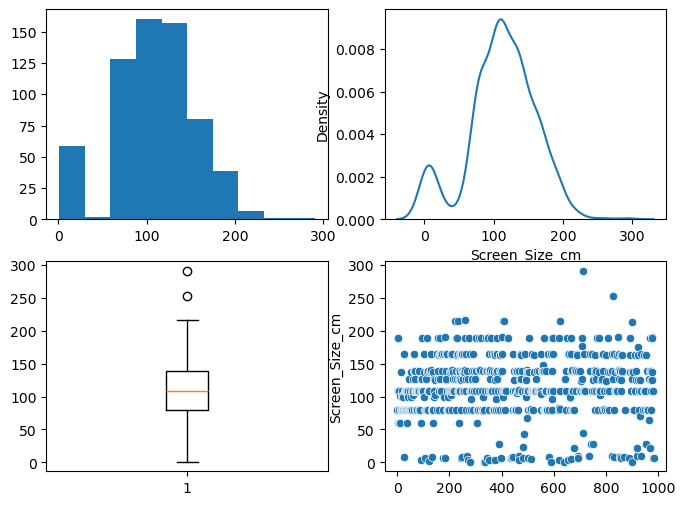

-----------------Launch_Year-----------------


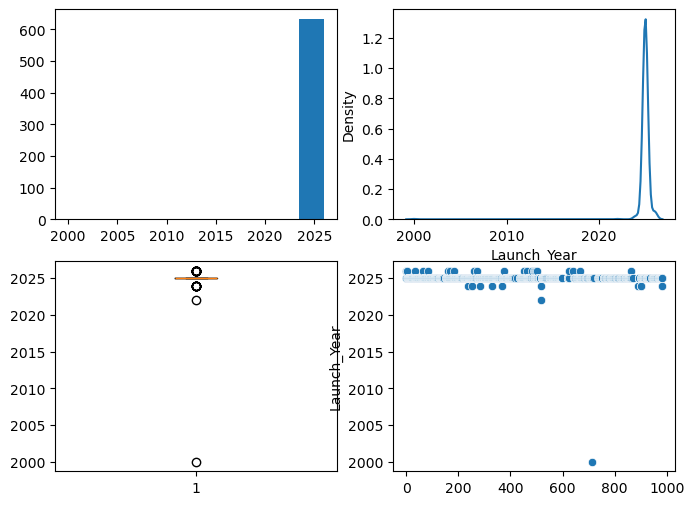

-----------------Rating-----------------


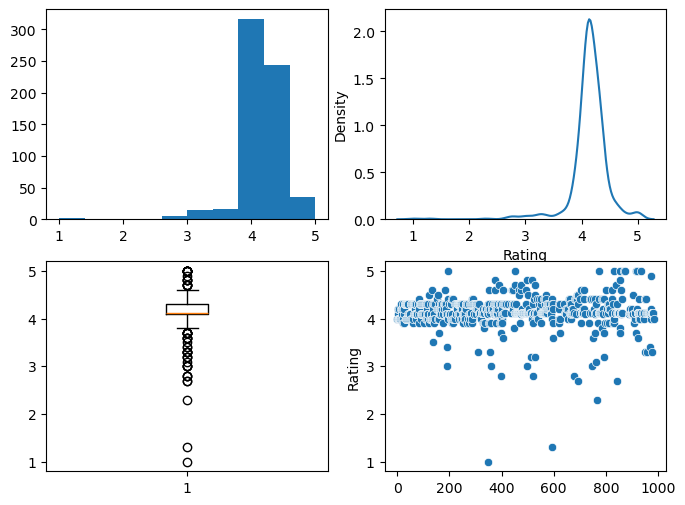

-----------------Price-----------------


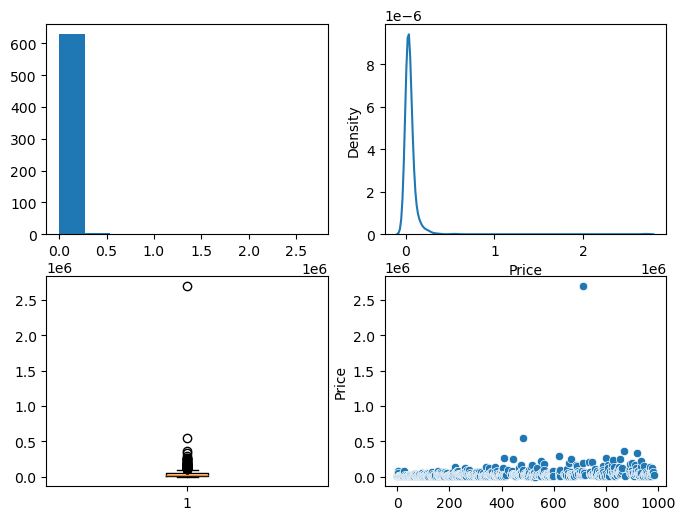

In [30]:
for col in num_cols:
    print(f"-----------------{col}-----------------")
    fig,ax = plt.subplots(2,2,figsize = (8,6))
    ax[0,0].hist(df[col])
    sns.kdeplot(df[col],ax = ax[0,1])
    ax[1,0].boxplot(df[col])
    sns.scatterplot(df[col],ax = ax[1,1])
    plt.show()

## Analysis
### Screen Size
----> From the graph, we can see that most of the TVs have screen sizes between 100 cm and 140 cm, which shows that medium-sized TVs are more common and widely preferred.                 
----> The screen size distribution is slightly right-skewed, meaning there are more larger TVs available compared to very small ones.                                   
----> The boxplot shows a few outliers at both ends. This means TVs with very small screen sizes and very large screen sizes are present, but they are not common.                             
----> The scatter plot shows that TVs come in many different screen sizes.                          

### Launch Year
----> Most of the TVs in the dataset were launched in 2025.                    
----> Very few TVs belong to earlier years like 2023 and 2024, which appear less frequent.           
----> The boxplot shows older launch years as outliers, meaning they are not common compared to 2025 model.

### Rating
----> Most TVs have ratings between 4.0 and 4.5, which shows that the majority of products are well-rated by customers. 
----> The distribution is slightly left-skewed, meaning there are fewer TVs with very low ratings compared to high ratings.                                                 
----> The boxplot shows a few low-rated TVs as outliers, indicating that poor ratings exist but are not common.                                                     
----> The scatter plot shows that ratings are consistently high across many products.

### Price
----> Most TVs are priced between Rs.10,000 and Rs.40,000, which is the most common range.          
---->The price distribution is right-skewed, with prices going up to around Rs.2,50,000 for a few models.                                                                                    
---->The boxplot shows many high-price outliers above Rs.70,000 indicating premium TVs.             
---->Overall, prices vary widely from below Rs.10,000 to above Rs.2,00,000, offering both budget and high-end options.

<Axes: xlabel='Screen_Size_cm'>

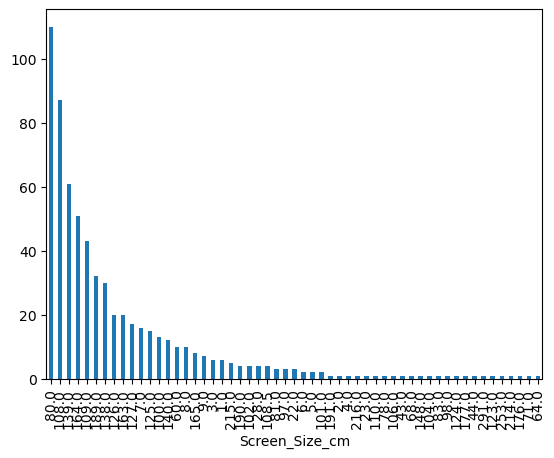

In [31]:
df['Screen_Size_cm'].value_counts().plot(kind = 'bar')

### Analysis on barplot of `Screen_Size_cm`
Most TVs in the dataset have small to medium screen sizes especially around 80 cm which are the most common. As screen size increases the number of TVs decreases showing that very large screens are less common.

<Axes: xlabel='Launch_Year'>

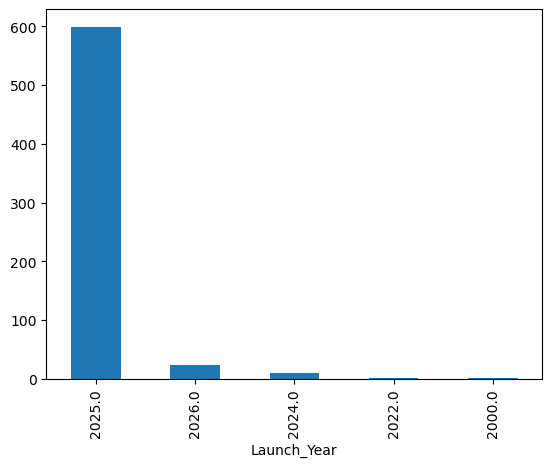

In [32]:
df['Launch_Year'].value_counts().plot(kind = 'bar')

#### Analysis on barplot of `Launch_Year`
----> Most TVs in the dataset were launched in 2025, showing a strong focus on recent models.        
----> Very few TVs belong to earlier years like 2026 and 2024, indicating limited older listings.

<Axes: xlabel='Rating'>

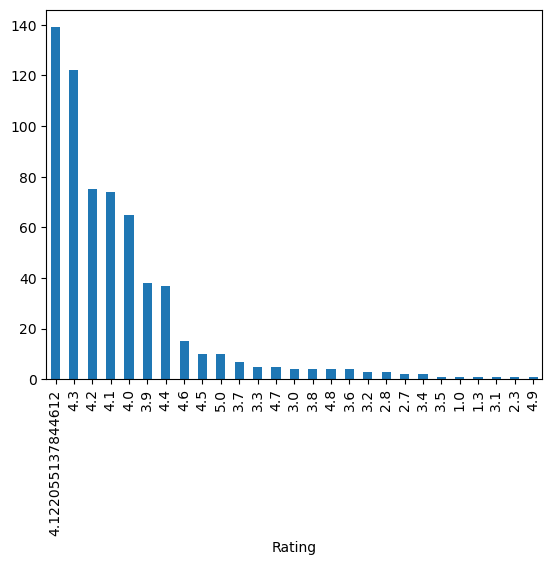

In [33]:
df['Rating'].value_counts().plot(kind = 'bar')

### Analysis on barplot of `Rating`
----> Most TVs have ratings between 4.0 and 4.3, indicating generally good customer satisfaction.

<Axes: ylabel='Frequency'>

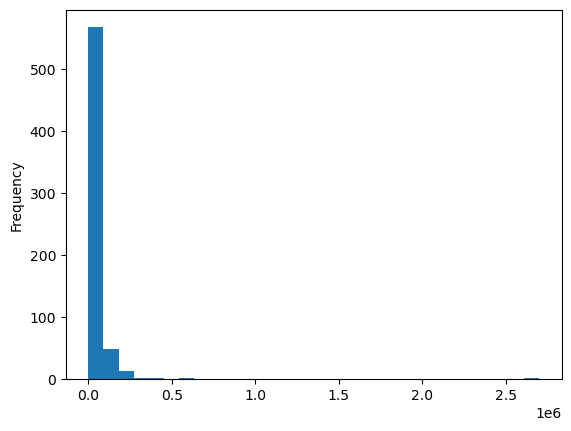

In [34]:
df['Price'].plot(kind='hist', bins=30)

### Analysis on histogram of `Price`
----> Most TVs are concentrated in the lower to mid price range (₹10,000–₹40,000), indicating a strong budget-friendly market. 
----> The distribution is highly right-skewed, with very few high-priced TVs, creating a long tail. A small number of premium TVs act as outliers in the dataset.

<Axes: ylabel='count'>

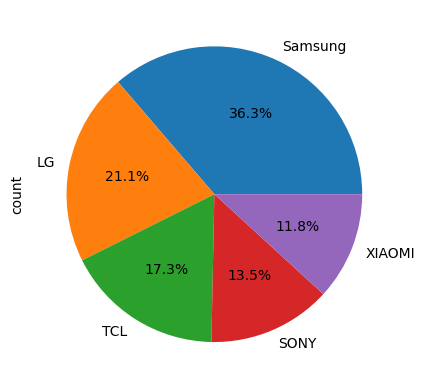

In [35]:
df['Brand'].value_counts().head().plot(kind='pie', autopct='%1.1f%%')

### Analysis on Piechart of `Brand`
----> Samsung dominates the market (38%), followed by LG (23%) and TCL (18%). The top two brands contribute over 50% of the total share, indicating a moderately concentrated but competitive market.

### Univariate analysis on categorical cols

In [36]:
## non-visualization analysis
cat_cols = df.select_dtypes(include = ['object','category']).columns.values
for col in cat_cols:
    print(f"-----------------{col}-----------------")
    print("Mode: ",df[col].mode())
    print("Frequency: ",df[col].value_counts())
    print("Proportions: ",df[col].value_counts(normalize = True))

-----------------Brand-----------------
Mode:  0    Samsung
Name: Brand, dtype: object
Frequency:  Brand
Samsung     86
LG          50
TCL         41
SONY        32
XIAOMI      28
            ..
Akai         1
Hyundai      1
LUGOSI       1
Swan         1
TRUSENSE     1
Name: count, Length: 71, dtype: int64
Proportions:  Brand
Samsung     0.135647
LG          0.078864
TCL         0.064669
SONY        0.050473
XIAOMI      0.044164
              ...   
Akai        0.001577
Hyundai     0.001577
LUGOSI      0.001577
Swan        0.001577
TRUSENSE    0.001577
Name: proportion, Length: 71, dtype: float64
-----------------Resolution-----------------
Mode:  0    4K Ultra HD
Name: Resolution, dtype: object
Frequency:  Resolution
4K Ultra HD    430
HD Ready       122
Full HD         82
Name: count, dtype: int64
Proportions:  Resolution
4K Ultra HD    0.678233
HD Ready       0.192429
Full HD        0.129338
Name: proportion, dtype: float64
-----------------TV_Type-----------------
Mode:  0    LED
N

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation = 90)
C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation = 90)


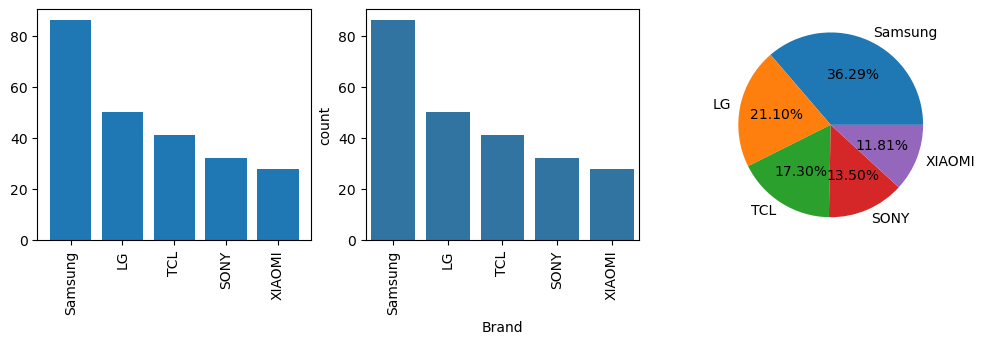

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation = 90)
C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation = 90)


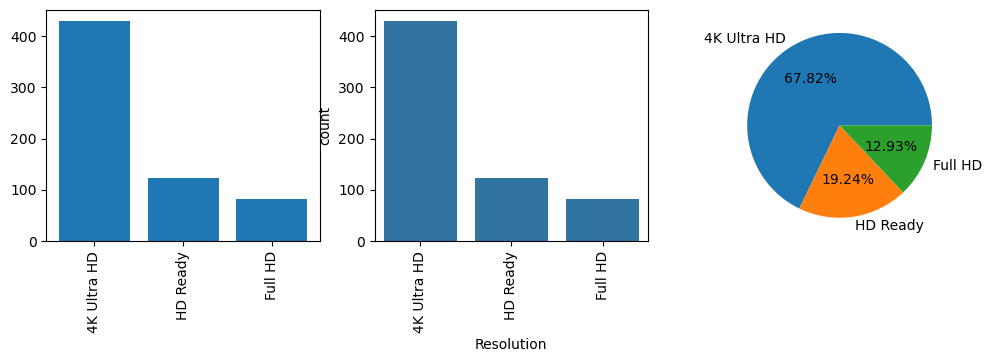

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation = 90)
C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation = 90)


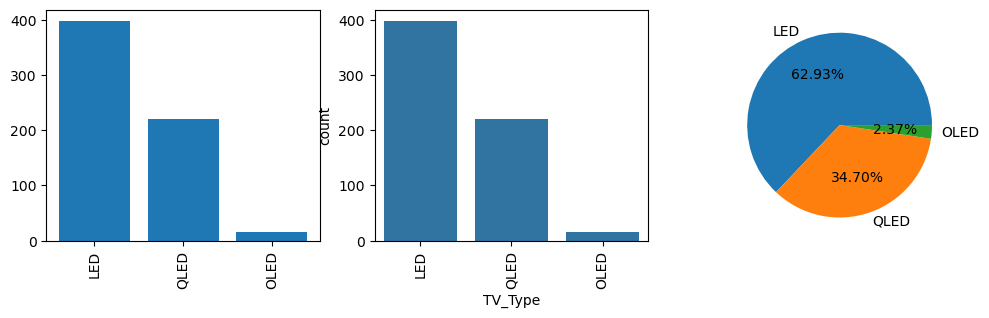

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation = 90)
C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\3805036891.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation = 90)


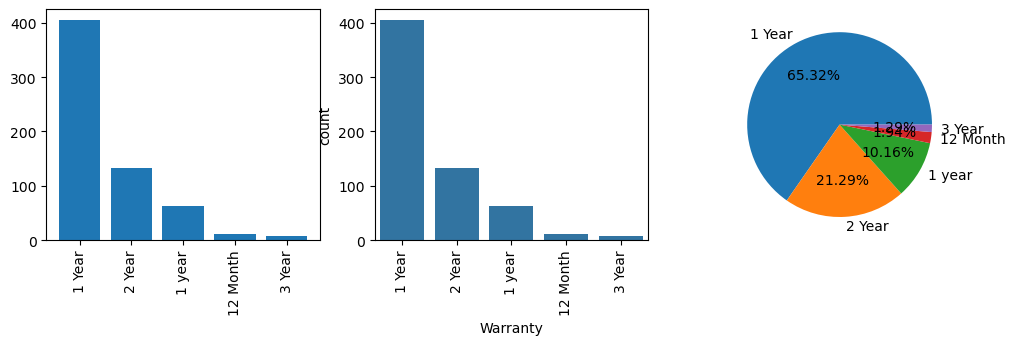

In [37]:
## Visualization: Barplot, Countplot, Pie plot
for col in cat_cols:  
    vc = df[col].value_counts()
    top10 = vc.head()
    fig,ax = plt.subplots(1,3,figsize = (12,3))
    ax[0].bar(top10.index, height = top10.values)
    sns.countplot(data = df, x = col, order = top10.index, ax = ax[1])
    ax[2].pie(top10, labels = top10.index, autopct = "%.2f%%")
    ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation = 90)
    ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation = 90)
    plt.show()

#### ANALYSIS ON `BRAND`
----> Only a few brands sell most of the TVs, while many brands sell very few.                       
----> Samsung has the highest share followed by LG and the rest of the brands have much smaller shares.

#### ANALYSIS ON `RESOLUTION`
----> The chart shows that most TVs are 4K Ultra HD, making up the largest share of the data.        
----> HD Ready comes next, while Full HD models are very few compared to the other.        

#### ANALYSIS ON `TV_TYPE` 
----> The graph shows that LED TVs are the most common, followed by QLED TVs.                
----> OLED TVs are very few, which means they are less popular or less available compared to the other types.                                                      

#### ANALYSIS ON `WARRANTY`
----> The graph shows that 1 Year warranty are the most common, followed by 2 Years. 

In [38]:
### Bivariate analysis - num-num, num-cat, cat-cat
### Non Visualization: num-num - correlation coefficients
df[['Price','Rating']].corr()

,Price,Rating
Price,1.000000,0.086043
Rating,0.086043,1.000000


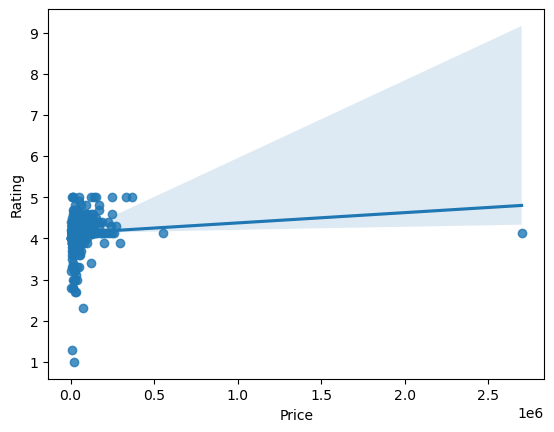

In [39]:
### Visualization - num to num
sns.regplot(data = df,x = "Price",y = "Rating")
plt.show()

### VISUALIZATION ON `PRICE` AND `RATING`
----> Ratings increase a little as price increases, but the change is very small.                  
----> Overall, price does not have a strong impact on ratings since most values stay around 4.

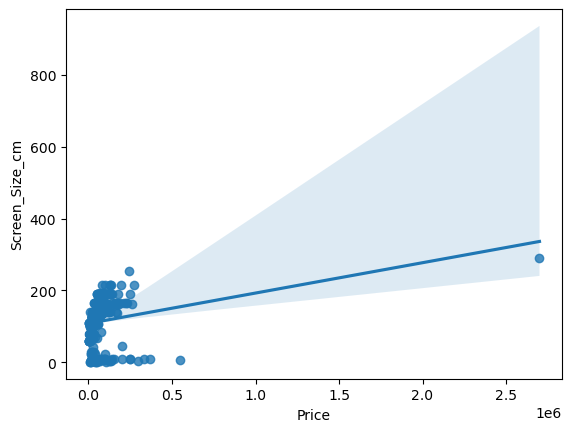

In [60]:
### Visualization - Price to Screen_Size_cm
sns.regplot(data = df,x = "Price",y = "Screen_Size_cm")
plt.show()

### VISUALIZATION ON `PRICE` AND `Screen_Size_cm`
----> There is a positive correlation between price and screen size, but the relationship is not strictly linear, indicating that additional features also influence TV pricing.                                          
----> The spread of data points suggests moderate correlation rather than a strong linear relationship.

In [40]:
cat_cols

array(['Brand', 'Resolution', 'TV_Type', 'Warranty'], dtype=object)

In [41]:
### non-visulization
ct=pd.crosstab(df['Resolution'],df['TV_Type'])

In [42]:
ct

TV_Type,LED,OLED,QLED
Resolution,,,
4K Ultra HD,242,15,173
Full HD,65,0,17
HD Ready,92,0,30


<Axes: xlabel='Resolution'>

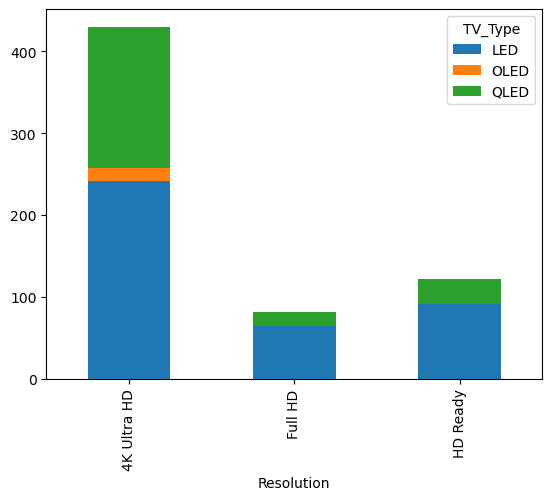

In [43]:
ct.plot(kind='bar',stacked=True)

### ANALYSIS ON `RESOLUTION`
----> From the stacked bar chart, 4K Ultra HD TVs are the most common, mainly dominated by LED and QLED types. 


In [44]:
ct1 = pd.crosstab(df['TV_Type'],df['Warranty'])
ct1

Warranty,1 YEAR,1 Year,1 year,12 Month,12 month,2 Year,2 year,2year,3 Year,3 year,5 year
TV_Type,,,,,,,,,,,
LED,1,279,34,10,4,67,1,0,3,0,0
OLED,0,6,1,0,0,3,0,0,1,4,0
QLED,0,120,28,2,0,62,0,1,4,0,3


In [45]:
ct2 = pd.crosstab(df['Warranty'],df['Resolution'])
ct2

Resolution,4K Ultra HD,Full HD,HD Ready
Warranty,,,
1 YEAR,1,0,0
1 Year,247,65,93
1 year,41,6,16
12 Month,6,2,4
12 month,0,3,1
2 Year,120,6,6
2 year,0,0,1
2year,1,0,0
3 Year,7,0,1


<Axes: xlabel='Warranty'>

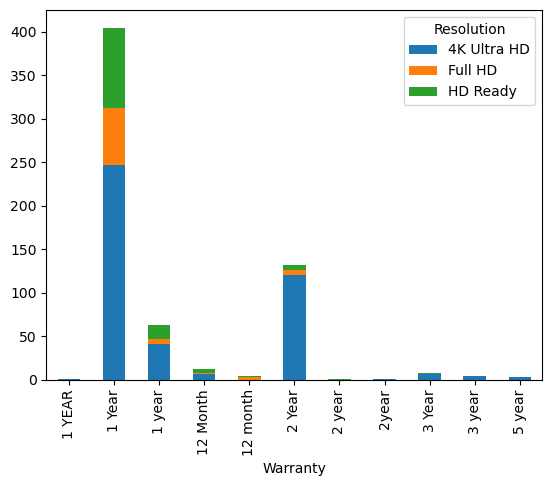

In [46]:
ct2.plot(kind = "bar", stacked = True)

### ANALYSIS ON `WARRANTY`
----> From the stacked bar chart, most TVs come with a 1-year warranty, and this is mainly seen in 4K Ultra HD models.                                          
----> Other warranty periods like 2 or 3 years are available but in much smaller numbers.

<Axes: xlabel='TV_Type', ylabel='count'>

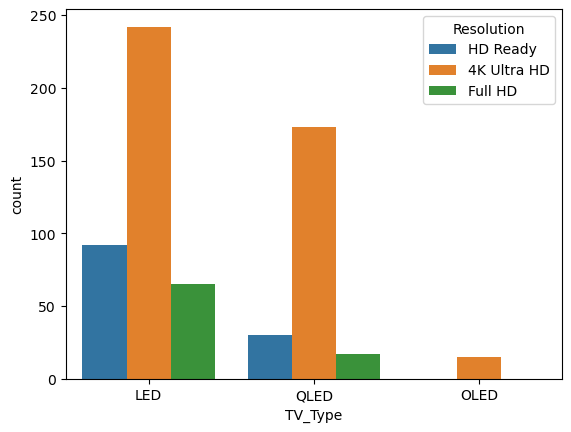

In [47]:
sns.countplot(data = df, x = "TV_Type", hue = "Resolution" )

### ANALYSIS ON `TV_TYPE`
----> From the count plot, LED TVs are the most common, followed by QLED, while OLED TVs are very few.                                      
----> Most TVs especially LED and QLED come with 4K Ultra HD resolution showing it is the most popular resolution.

In [48]:
#### num-cat cols
## Brand, Resolution
s=df.groupby('Resolution')

In [49]:
s.groups

{'4K Ultra HD': [1, 4, 13, 16, 25, 27, 38, 40, 45, 49, 54, 58, 62, 63, 64, 66, 67, 68, 69, 70, 73, 84, 85, 91, 92, 93, 95, 98, 102, 103, 105, 109, 111, 113, 114, 115, 116, 117, 122, 123, 124, 128, 129, 130, 131, 134, 138, 140, 145, 152, 155, 156, 157, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 172, 173, 175, 178, 182, 183, 184, 185, 186, 187, 188, 189, 199, 202, 203, 205, 207, 208, 209, 210, 212, 213, 215, 218, 222, 223, 225, 226, 227, 228, 230, 231, 232, 234, 235, 236, ...], 'Full HD': [2, 6, 9, 17, 18, 22, 29, 32, 35, 39, 42, 52, 59, 61, 72, 74, 78, 79, 83, 94, 99, 104, 118, 139, 141, 142, 143, 179, 190, 194, 204, 206, 255, 282, 293, 324, 330, 338, 344, 349, 354, 358, 363, 372, 374, 397, 399, 406, 463, 465, 478, 489, 492, 503, 508, 529, 533, 553, 569, 571, 593, 596, 620, 623, 624, 655, 663, 669, 675, 679, 743, 792, 793, 806, 835, 872, 926, 928, 929, 949, 953, 971], 'HD Ready': [0, 3, 5, 7, 8, 10, 11, 12, 14, 15, 19, 20, 21, 23, 24, 28, 33, 34, 36, 37, 41, 46, 47, 48, 53, 

In [50]:
s['Price'].agg(["mean","median","sum","count","min","max"])

,mean,median,sum,count,min,max
Resolution,,,,,,
4K Ultra HD,66525.500000,41244.5,28605965.0,430,853.0,2699990.0
Full HD,18075.195122,15999.0,1482166.0,82,8414.0,42999.0
HD Ready,12665.286885,11994.5,1545165.0,122,4799.0,29999.0


In [51]:
 pt = df.pivot_table(index = "Resolution", values = "Price",aggfunc = ["mean","median","sum","count","min","max"])

In [52]:
pt.stack()

C:\Users\Yenni Bhavana\AppData\Local\Temp\ipykernel_18188\1655581180.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pt.stack()


,,mean,median,sum,count,min,max
Resolution,,,,,,,
4K Ultra HD,Price,66525.500000,41244.5,28605965.0,430,853.0,2699990.0
Full HD,Price,18075.195122,15999.0,1482166.0,82,8414.0,42999.0
HD Ready,Price,12665.286885,11994.5,1545165.0,122,4799.0,29999.0


In [53]:
g = df.groupby(['Brand','TV_Type'])['Price'].agg(["mean","median","sum","count","min","max"])

In [54]:
g

mean   median       sum  count      min      max
Brand    TV_Type                                                          
Acer     LED      23915.666667  22749.0  143494.0      6   9999.0  43999.0
         QLED     25940.000000  24999.0  181580.0      7  11999.0  35999.0
Aiwa     QLED     39548.000000  39548.0   39548.0      1  39548.0  39548.0
Akai     LED      12790.000000  12790.0   12790.0      1  12790.0  12790.0
Asiano   LED       8765.000000   8765.0   17530.0      2   8295.0   9235.0
...                        ...      ...       ...    ...      ...      ...
iFFALCON LED      28721.222222  25999.0  258491.0      9   8399.0  52999.0
iMEE     LED      27745.500000  27745.5   55491.0      2  27652.0  27839.0
realme   LED      30141.857143  26499.0  210993.0      7  19499.0  38999.0
         QLED     32699.000000  25249.0  326990.0     10  10499.0  99999.0
skylive  LED      12765.250000  14001.5   51061.0      4   7759.0  15299.0

[106 rows x 6 columns]

In [55]:
g.unstack()

mean                      median                     sum  \
TV_Type            LED OLED          QLED      LED OLED     QLED       LED   
Brand                                                                        
Acer      23915.666667  NaN  25940.000000  22749.0  NaN  24999.0  143494.0   
Aiwa               NaN  NaN  39548.000000      NaN  NaN  39548.0       NaN   
Akai      12790.000000  NaN           NaN  12790.0  NaN      NaN   12790.0   
Asiano     8765.000000  NaN           NaN   8765.0  NaN      NaN   17530.0   
BESTON    11265.666667  NaN  35432.333333  11799.0  NaN  36999.0   33797.0   
...                ...  ...           ...      ...  ...      ...       ...   
acerpure  12499.000000  NaN  48449.000000  12499.0  NaN  48449.0   12499.0   
iFFALCON  28721.222222  NaN           NaN  25999.0  NaN      NaN  258491.0   
iMEE      27745.500000  NaN           NaN  27745.5  NaN      NaN   55491.0   
realme    30141.857143  NaN  32699.000000  26499.0  NaN  25249.0  210993.0   
skylive   12765.250000  NaN           NaN  14001.5  NaN      NaN   51061.0   

                        count                 min                    max       \
TV_Type  OLED      QLED   LED OLED  QLED      LED OLED     QLED      LED OLED   
Brand                                                                           
Acer      NaN  181580.0   6.0  NaN   7.0   9999.0  NaN  11999.0  43999.0  NaN   
Aiwa      NaN   39548.0   NaN  NaN   1.0      NaN  NaN  39548.0      NaN  NaN   
Akai      NaN       NaN   1.0  NaN   NaN  12790.0  NaN      NaN  12790.0  NaN   
Asiano    NaN       NaN   2.0  NaN   NaN   8295.0  NaN      NaN   9235.0  NaN   
BESTON    NaN  106297.0   3.0  NaN   3.0   8499.0  NaN  19799.0  13499.0  NaN   
...       ...       ...   ...  ...   ...      ...  ...      ...      ...  ...   
acerpure  NaN   96898.0   1.0  NaN   2.0  12499.0  NaN  43399.0  12499.0  NaN   
iFFALCON  NaN       NaN   9.0  NaN   NaN   8399.0  NaN      NaN  52999.0  NaN   
iMEE      NaN       NaN   2.0  NaN   NaN  27652.0  NaN      NaN  27839.0  NaN   
realme    NaN  326990.0   7.0  NaN  10.0  19499.0  NaN  10499.0  38999.0  NaN   
skylive   NaN       NaN   4.0  NaN   NaN   7759.0  NaN      NaN  15299.0  NaN   

                   
TV_Type      QLED  
Brand              
Acer      35999.0  
Aiwa      39548.0  
Akai          NaN  
Asiano        NaN  
BESTON    49499.0  
...           ...  
acerpure  53499.0  
iFFALCON      NaN  
iMEE          NaN  
realme    99999.0  
skylive       NaN  

[71 rows x 18 columns]

In [56]:
g.loc[('Asiano','LED'),'mean']

np.float64(8765.0)

In [57]:
### Multivariate analysis
### Bivariate analysis : hue parametter, multivariate analysis
### Univariate: hue parameter - Bivariate analysis

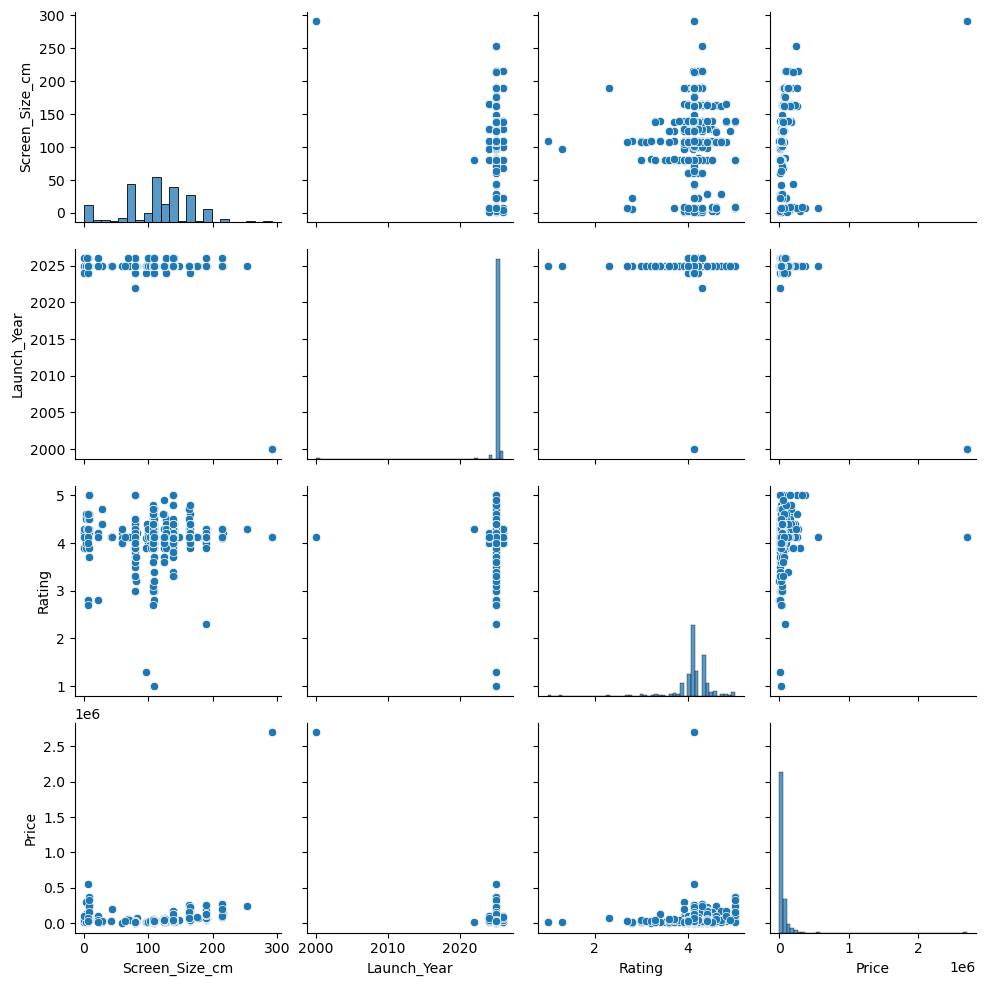

In [58]:
### All numerical columns -> sns.pairplot--> scatter plot drawn for two numerical columns
### Numerical columns -> correlation heatmap
sns.pairplot(data = df)

<Axes: >

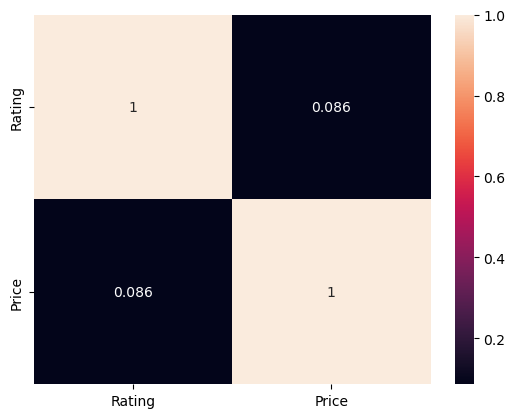

In [59]:
sns.heatmap(df[['Rating','Price']].corr(),annot = True)

#### ANALYSIS OF HEATMAP ON `PRICE` AND `RATING`
----> The heatmap shows a weak positive relationship between rating and price. This means that higher-priced TVs do not always have higher ratings.

### OVERALL ANALYSIS
----> Most TVs in the dataset are LED type, followed by QLED, while OLED TVs are very few.           
----> 4K Ultra HD is the most common resolution across all TV types.                         
----> The majority of TVs were launched in 2025.                                
----> Medium screen sizes are more popular compared to very large screens.                   
----> Ratings are mostly between 4.0 and 4.3, indicating good customer satisfaction.           
----> There is a weak relationship between price and rating, so higher price does not always mean better rating.                                   
----> Most TVs come with a 1-year warranty, which is the standard across resolutions.                                                 
----> The price range is around 20,000 - 50,000. This shows that most TVs are affordable.

### Key Analysis
*  Majority of TVs fall in the **mid-range price segment**, indicating strong demand in affordable categories.
*  Ratings are relatively consistent across price ranges, suggesting **higher price does not always guarantee better ratings**.
*  Certain brands dominate the market with a larger number of listings.
*  LED TVs are the most common, showing widespread adoption due to affordability.
*  Features like screen size and display technology influence pricing significantly.